In [2]:
# --- CELL 1: SETUP ---
import os
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [3]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    task: str
    candidate_solution: str
    evaluation_score: float  # 0 to 10 scale
    feedback: str
    accepted: bool

In [5]:
# --- CELL 3: THE WORKERS (NODES) ---

def optimizer_node(state: SentinelState):
    """Generates or improves a solution based on feedback."""
    print("🎨 Optimizer: Generating/Improving solution...")

    if not state.get("candidate_solution"):
        solution = "To invest in stocks, just buy what is popular."
    else:
        # Improving based on feedback
        solution = "A balanced investment strategy involves diversifying across sectors (Tech, Health, Energy) and using Dollar Cost Averaging."

    return {"candidate_solution": solution}

def evaluator_node(state: SentinelState):
    """Grades the solution and provides specific feedback."""
    print("⚖️ Evaluator: Grading solution...")
    solution = state["candidate_solution"]

    # Mock grading logic
    if "diversifying" in solution.lower():
        return {
            "evaluation_score": 9.5,
            "feedback": "Comprehensive and professional.",
            "accepted": True
        }
    else:
        return {
            "evaluation_score": 3.0,
            "feedback": "Too simplistic. Needs to mention diversification.",
            "accepted": False
        }

In [6]:
# --- CELL 4: THE DECISION LOGIC ---
def check_approval(state: SentinelState):
    """Directs the flow based on the Evaluator's grade."""
    if state["accepted"]:
        print("✅ Solution Accepted!")
        return "finish"

    print(f"❌ Solution Rejected (Score: {state['evaluation_score']}). Retrying...")
    return "retry"

In [7]:
# --- CELL 5: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

builder.add_node("optimizer", optimizer_node)
builder.add_node("evaluator", evaluator_node)

builder.add_edge(START, "optimizer")
builder.add_edge("optimizer", "evaluator")

# Routing based on the grade
builder.add_conditional_edges(
    "evaluator",
    check_approval,
    {
        "retry": "optimizer",
        "finish": END
    }
)

sentinel_eval_opt = builder.compile()

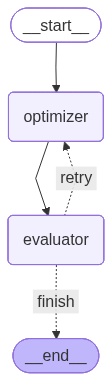

In [8]:
# --- CELL 6: VISUALIZATION ---
try:
    png_bytes = sentinel_eval_opt.get_graph().draw_mermaid_png()
    with open("sentinel_eval_opt.png", "wb") as f:
        f.write(png_bytes)
    display(Image(data=png_bytes))
except Exception as e:
    print(f"Visualization skip: {e}")

In [9]:
# --- CELL 7: RUNNING THE LINE ---
print("\n--- STARTING EVALUATOR-OPTIMIZER CYCLE ---")
result = sentinel_eval_opt.invoke({"task": "Write a basic investment strategy."})
print("\n" + "="*30)
print(f"FINAL APPROVED SOLUTION:\n{result['candidate_solution']}")
print("="*30)


--- STARTING EVALUATOR-OPTIMIZER CYCLE ---
🎨 Optimizer: Generating/Improving solution...
⚖️ Evaluator: Grading solution...
❌ Solution Rejected (Score: 3.0). Retrying...
🎨 Optimizer: Generating/Improving solution...
⚖️ Evaluator: Grading solution...
✅ Solution Accepted!

FINAL APPROVED SOLUTION:
A balanced investment strategy involves diversifying across sectors (Tech, Health, Energy) and using Dollar Cost Averaging.
